# Residential Building Function Filter

This notebook selects the main residential building stock from the original Hamburg ALKIS building dataset using explicit `gebaeudefunktion` codes.

It does not use the broad `1000-1999` rule. Only the codes listed below are included in the main residential stock.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/raw/hamburg_buildings_clean.gpkg")
PROCESSED_DIR = Path("../data/processed")
FIGURE_DIR = Path("../results/figures")
RESIDENTIAL_OUTPUT_PATH = PROCESSED_DIR / "hamburg_main_residential_buildings_by_function.gpkg"
SUMMARY_OUTPUT_PATH = PROCESSED_DIR / "hamburg_residential_function_filter_summary.csv"
RESIDENTIAL_CLASS_DISTRIBUTION_FIGURE_PATH = FIGURE_DIR / "hamburg_main_residential_function_class_distribution.png"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)


## Residential Function Codes


In [2]:
MAIN_RESIDENTIAL_FUNCTION_CODES = {
    1010: "Wohnhaus",
    1020: "Wohnheim",
    1100: "Gemischt genutztes Gebaeude mit Wohnen",
    1110: "Wohngebaeude mit Gemeinbedarf",
    1120: "Wohngebaeude mit Handel und Dienstleistungen",
    1130: "Wohngebaeude mit Gewerbe und Industrie",
    1210: "Land- und forstwirtschaftliches Wohngebaeude",
    1220: "Land- und forstwirtschaftliches Wohn- und Betriebsgebaeude",
}

MAIN_RESIDENTIAL_FUNCTION_CODES_EN = {
    1010: "Residential building",
    1020: "Dormitory / residential home",
    1100: "Mixed-use building with housing",
    1110: "Residential building with community facilities",
    1120: "Residential building with retail and services",
    1130: "Residential building with commercial/industrial use",
    1210: "Agricultural/forestry residential building",
    1220: "Agricultural/forestry residential and operational building",
}

EXCLUDED_RESIDENTIAL_RELATED_CODES_EN = {
    1311: "Holiday house",
    1312: "Weekend house",
    1313: "Garden house",
}

EXCLUDED_RESIDENTIAL_RELATED_CODES = {
    1311: "Ferienhaus",
    1312: "Wochenendhaus",
    1313: "Gartenhaus",
}

MAIN_RESIDENTIAL_CODE_SET = set(MAIN_RESIDENTIAL_FUNCTION_CODES)
EXCLUDED_RESIDENTIAL_RELATED_CODE_SET = set(EXCLUDED_RESIDENTIAL_RELATED_CODES)

pd.DataFrame(
    [
        {"code": code, "label_de": label, "label_en": MAIN_RESIDENTIAL_FUNCTION_CODES_EN[code], "filter_decision": "included_main_residential_stock"}
        for code, label in MAIN_RESIDENTIAL_FUNCTION_CODES.items()
    ]
    + [
        {"code": code, "label_de": label, "label_en": EXCLUDED_RESIDENTIAL_RELATED_CODES_EN[code], "filter_decision": "excluded_residential_related_non_permanent_or_ancillary"}
        for code, label in EXCLUDED_RESIDENTIAL_RELATED_CODES.items()
    ]
)


,code,label_de,label_en,filter_decision
0,1010,Wohnhaus,Residential building,included_main_residential_stock
1,1020,Wohnheim,Dormitory / residential home,included_main_residential_stock
2,1100,Gemischt genutztes Gebaeude mit Wohnen,Mixed-use building with housing,included_main_residential_stock
3,1110,Wohngebaeude mit Gemeinbedarf,Residential building with community facilities,included_main_residential_stock
4,1120,Wohngebaeude mit Handel und Dienstleistungen,Residential building with retail and services,included_main_residential_stock
5,1130,Wohngebaeude mit Gewerbe und Industrie,Residential building with commercial/industria...,included_main_residential_stock
6,1210,Land- und forstwirtschaftliches Wohngebaeude,Agricultural/forestry residential building,included_main_residential_stock
7,1220,Land- und forstwirtschaftliches Wohn- und Betr...,Agricultural/forestry residential and operatio...,included_main_residential_stock
8,1311,Ferienhaus,Holiday house,excluded_residential_related_non_permanent_or_...
9,1312,Wochenendhaus,Weekend house,excluded_residential_related_non_permanent_or_...


## Load Original Hamburg Buildings


In [3]:
gdf = gpd.read_file(DATA_PATH)
gdf["building_function"] = pd.to_numeric(gdf["gebaeudefunktion"], errors="coerce").astype("Int64")

print("Original buildings:", len(gdf))
print("CRS:", gdf.crs)
gdf[["gebaeudefunktion", "building_function", "bauweise", "baujahr"]].head()


Original buildings: 379320
CRS: EPSG:25832


,gebaeudefunktion,building_function,bauweise,baujahr
0,1010,1010,1100,NULL
1,1010,1010,1100,NULL
2,1010,1010,1100,NULL
3,1010,1010,1100,1997
4,1010,1010,2200,1978


## Apply Residential Function Filter


In [4]:
gdf["is_main_residential_stock"] = gdf["building_function"].isin(MAIN_RESIDENTIAL_CODE_SET)
gdf["is_excluded_residential_related"] = gdf["building_function"].isin(EXCLUDED_RESIDENTIAL_RELATED_CODE_SET)

gdf["building_function_filter_decision"] = "other_non_residential_or_out_of_scope"
gdf.loc[gdf["is_main_residential_stock"], "building_function_filter_decision"] = "included_main_residential_stock"
gdf.loc[gdf["is_excluded_residential_related"], "building_function_filter_decision"] = "excluded_residential_related_non_permanent_or_ancillary"

function_labels = {**MAIN_RESIDENTIAL_FUNCTION_CODES, **EXCLUDED_RESIDENTIAL_RELATED_CODES}
function_labels_en = {**MAIN_RESIDENTIAL_FUNCTION_CODES_EN, **EXCLUDED_RESIDENTIAL_RELATED_CODES_EN}
gdf["building_function_label"] = gdf["building_function"].map(function_labels).fillna("other_or_unmapped")
gdf["building_function_label_en"] = gdf["building_function"].map(function_labels_en).fillna("other_or_unmapped")

filter_summary = (
    gdf.groupby("building_function_filter_decision", dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)
filter_summary["share_of_all_buildings_pct"] = (filter_summary["building_count"] / len(gdf) * 100).round(2)
display(filter_summary)

code_summary = (
    gdf.groupby(["gebaeudefunktion", "building_function", "building_function_label", "building_function_label_en", "building_function_filter_decision"], dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)
code_summary["share_of_all_buildings_pct"] = (code_summary["building_count"] / len(gdf) * 100).round(2)
display(code_summary.head(30))


,building_function_filter_decision,building_count,share_of_all_buildings_pct
1,included_main_residential_stock,227334,59.93
2,other_non_residential_or_out_of_scope,111559,29.41
0,excluded_residential_related_non_permanent_or_...,40427,10.66


,gebaeudefunktion,building_function,building_function_label,building_function_label_en,building_function_filter_decision,building_count,share_of_all_buildings_pct
0,1010,1010,Wohnhaus,Residential building,included_main_residential_stock,205239,54.11
44,2463,2463,other_or_unmapped,other_or_unmapped,other_non_residential_or_out_of_scope,60920,16.06
10,1313,1313,Gartenhaus,Garden house,excluded_residential_related_non_permanent_or_...,40081,10.57
4,1120,1120,Wohngebaeude mit Handel und Dienstleistungen,Residential building with retail and services,included_main_residential_stock,9852,2.60
2,1100,1100,Gemischt genutztes Gebaeude mit Wohnen,Mixed-use building with housing,included_main_residential_stock,8646,2.28
27,2140,2140,other_or_unmapped,other_or_unmapped,other_non_residential_or_out_of_scope,6071,1.60
12,2020,2020,other_or_unmapped,other_or_unmapped,other_non_residential_or_out_of_scope,5229,1.38
46,2465,2465,other_or_unmapped,other_or_unmapped,other_non_residential_or_out_of_scope,4936,1.30
64,2740,2740,other_or_unmapped,other_or_unmapped,other_non_residential_or_out_of_scope,2866,0.76
24,2120,2120,other_or_unmapped,other_or_unmapped,other_non_residential_or_out_of_scope,2839,0.75


## Distribution of Residential Function Classes Left for Analysis

Show how the selected main residential building stock is distributed across the included `gebaeudefunktion` classes.


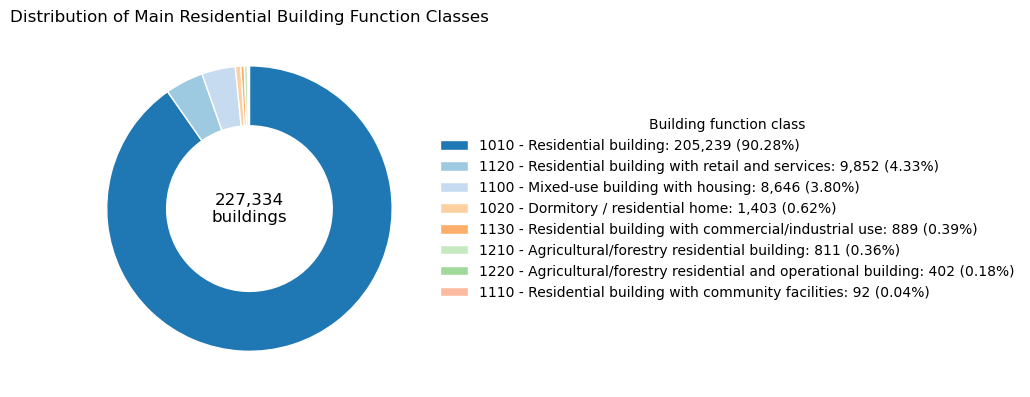

Output: ../results/figures/hamburg_main_residential_function_class_distribution.png


,building_function,building_function_label,building_function_label_en,building_count,share_of_selected_residential_stock_pct,plot_label
0,1010,Wohnhaus,Residential building,205239,90.28,1010 - Residential building
4,1120,Wohngebaeude mit Handel und Dienstleistungen,Residential building with retail and services,9852,4.33,1120 - Residential building with retail and se...
2,1100,Gemischt genutztes Gebaeude mit Wohnen,Mixed-use building with housing,8646,3.80,1100 - Mixed-use building with housing
1,1020,Wohnheim,Dormitory / residential home,1403,0.62,1020 - Dormitory / residential home
5,1130,Wohngebaeude mit Gewerbe und Industrie,Residential building with commercial/industria...,889,0.39,1130 - Residential building with commercial/in...
6,1210,Land- und forstwirtschaftliches Wohngebaeude,Agricultural/forestry residential building,811,0.36,1210 - Agricultural/forestry residential building
7,1220,Land- und forstwirtschaftliches Wohn- und Betr...,Agricultural/forestry residential and operatio...,402,0.18,1220 - Agricultural/forestry residential and o...
3,1110,Wohngebaeude mit Gemeinbedarf,Residential building with community facilities,92,0.04,1110 - Residential building with community fac...


In [5]:
residential_class_distribution = (
    gdf[gdf["is_main_residential_stock"]]
    .groupby(["building_function", "building_function_label", "building_function_label_en"], dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)
residential_class_distribution["share_of_selected_residential_stock_pct"] = (
    residential_class_distribution["building_count"]
    / residential_class_distribution["building_count"].sum()
    * 100
).round(2)
residential_class_distribution["plot_label"] = (
    residential_class_distribution["building_function"].astype("Int64").astype("string")
    + " - "
    + residential_class_distribution["building_function_label_en"].astype("string")
)

residential_class_colors = []
other_colors = ["#9ecae1", "#c6dbef", "#fdd0a2", "#fdae6b", "#c7e9c0", "#a1d99b", "#fcbba1"]
other_color_index = 0
for code in residential_class_distribution["building_function"]:
    if int(code) == 1010:
        residential_class_colors.append("#1f78b4")
    else:
        residential_class_colors.append(other_colors[other_color_index % len(other_colors)])
        other_color_index += 1

fig, ax = plt.subplots(figsize=(9, 7))
wedges, _ = ax.pie(
    residential_class_distribution["building_count"],
    colors=residential_class_colors,
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 1},
)
ax.set_title("Distribution of Main Residential Building Function Classes")
ax.text(
    0,
    0,
    f"{residential_class_distribution['building_count'].sum():,.0f}\nbuildings",
    ha="center",
    va="center",
    fontsize=12,
)

legend_labels = [
    f"{label}: {count:,.0f} ({share:.2f}%)"
    for label, count, share in zip(
        residential_class_distribution["plot_label"],
        residential_class_distribution["building_count"],
        residential_class_distribution["share_of_selected_residential_stock_pct"],
    )
]
ax.legend(
    wedges,
    legend_labels,
    title="Building function class",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
)
plt.tight_layout()

plt.savefig(RESIDENTIAL_CLASS_DISTRIBUTION_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Output:", RESIDENTIAL_CLASS_DISTRIBUTION_FIGURE_PATH)
display(residential_class_distribution)


## Export Main Residential Buildings


In [6]:
gdf_residential = gdf[gdf["is_main_residential_stock"]].copy()

gdf_residential.to_file(RESIDENTIAL_OUTPUT_PATH, driver="GPKG")
filter_summary.to_csv(SUMMARY_OUTPUT_PATH, index=False)

print("Main residential buildings:", len(gdf_residential))
print("Residential output:", RESIDENTIAL_OUTPUT_PATH)
print("Summary output:", SUMMARY_OUTPUT_PATH)

gdf_residential[[
    "gebaeudefunktion",
    "building_function",
    "building_function_label",
    "building_function_label_en",
    "building_function_filter_decision",
    "bauweise",
    "baujahr",
]].head()


Main residential buildings: 227334
Residential output: ../data/processed/hamburg_main_residential_buildings_by_function.gpkg
Summary output: ../data/processed/hamburg_residential_function_filter_summary.csv


,gebaeudefunktion,building_function,building_function_label,building_function_label_en,building_function_filter_decision,bauweise,baujahr
0,1010,1010,Wohnhaus,Residential building,included_main_residential_stock,1100,NULL
1,1010,1010,Wohnhaus,Residential building,included_main_residential_stock,1100,NULL
2,1010,1010,Wohnhaus,Residential building,included_main_residential_stock,1100,NULL
3,1010,1010,Wohnhaus,Residential building,included_main_residential_stock,1100,1997
4,1010,1010,Wohnhaus,Residential building,included_main_residential_stock,2200,1978
